In [1]:

import sys
if 'google.colab' in sys.modules:
    !pip install utdquake

lib = None
lib = "/home/emmanuel/ecastillo/dev/utdquake"
if lib is not None:
    sys.path.append(lib)

# Version (Required)

In [7]:
import utdquake
from packaging.version import Version

current_version = Version(utdquake.__version__)
required_version = Version("0.0.13")

if current_version < required_version:
    raise Exception(f"Please update utdquake to at least version {required_version}")

# UTDClient

## get custom stations

In [8]:
from utdquake.clients.fdsn.client import Client

provider = "texnet"
out = "./custom_events"

client =  Client(provider)
sta = client.get_custom_stations(output_folder=out,network="TX,4O",station="*")
print(sta.head(10))

      sta_id network station   latitude   longitude  elevation  \
0    4O.LWM1      4O    LWM1  31.231200 -103.630000      826.8   
1    4O.LWM2      4O    LWM2  31.269900 -103.584700      810.6   
2    4O.PR01      4O    PR01  31.236500 -103.270332      826.0   
3    4O.DB04      4O    DB04  31.066400 -103.105400      868.0   
4    4O.DB03      4O    DB03  31.116200 -103.078000      839.0   
5    4O.DB02      4O    DB02  31.185800 -103.109600      820.0   
7    4O.WB01      4O    WB01  31.721667 -104.060278      927.0   
8   4O.MBBB1      4O   MBBB1  32.246247 -101.891070      855.0   
9    4O.CF01      4O    CF01  32.801840 -100.583180      640.0   
10   4O.CT01      4O    CT01  31.902850 -104.144532      994.0   

                 starttime             endtime  \
0  2019-07-26 18:00:00.000 2030-11-04 20:44:14   
1  2019-07-26 18:00:00.000 2030-11-04 20:44:14   
2  2020-02-27 00:00:00.000 2030-11-04 20:44:14   
3  2021-02-22 01:05:58.000 2030-11-04 20:44:14   
4  2021-02-22 01:05:58.

## get custom events

In [9]:
from obspy import UTCDateTime
from utdquake.clients.fdsn.client import Client

region = [-104.84329,-103.79942,31.39610,31.91505]
provider = "USGS"
out = "./custom_events"

client =  Client(provider)
cat,picks,mag = client.get_custom_events(starttime=UTCDateTime("2024-04-18T23:00:00"),
                        endtime=UTCDateTime("2024-04-19T23:00:00"),
                        minlatitude=region[2], maxlatitude=region[3],
                        minlongitude=region[0], maxlongitude=region[1],
                        debug=True,
                        output_folder=out,
                        )


Event id 1/7: tx2024hrey
Event id 2/7: tx2024hrgy
Event id 3/7: tx2024hriz
Event id 4/7: tx2024hrlf
Event id 5/7: tx2024hrwl
Event id 6/7: tx2024hrwo
Event id 7/7: tx2024hstr


# How to read?

FIles in your ouput folder

In [10]:
import os
print(os.listdir(out))

['mags.db', 'stations.csv', 'picks.db', 'origin.csv']


picks and mags are in database format

In [11]:
import os

stations_path = os.path.join(out,"stations.csv")
events_path = os.path.join(out,"origin.csv")
picks_path = os.path.join(out,"picks.db")
mags_path = os.path.join(out,"mags.db")

read_stations

In [12]:
from utdquake.core.event.stations import Stations
help(Stations)

Help on class Stations in module utdquake.core.event.stations:

class Stations(utdquake.core.event.spatial.Points)
 |  Stations(*args, **kwargs) -> None
 |  
 |  A class representing seismic stations with additional attributes.
 |  
 |  Method resolution order:
 |      Stations
 |      utdquake.core.event.spatial.Points
 |      utdquake.core.event.data.DataFrameHelper
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, *args, **kwargs) -> None
 |      Initialize the Stations instance.
 |      
 |      Parameters:
 |      - *args: Positional arguments passed to the parent class.
 |      - **kwargs: Keyword arguments passed to the parent class.
 |  
 |  __str__(self, extended=False) -> str
 |      Return a string representation of the Stations instance.
 |  
 |  ----------------------------------------------------------------------
 |  Methods inherited from utdquake.core.event.spatial.Points:
 |  
 |  filter_by_r_az(self, latitude, longitude, r, az=None)
 |   

In [15]:
import pandas as pd
stations_data = pd.read_csv(stations_path)
stations = Stations(stations_data,xy_epsg="EPSG:3116",author="Texas")
print(stations)

Stations | 269 stations


data

In [16]:
stations.data

,sta_id,network,station,latitude,longitude,elevation,starttime,endtime,site_name,x[km],y[km],z[km]
0,TX.237B,TX,237B,32.001499,-95.808403,116.0,2018-12-19 22:30:00,NaN,"Washetta, Montalba, TX, USA",4248.666479,-1074.737594,-0.116
1,TX.435B,TX,435B,30.782700,-97.585000,248.0,2018-11-30 22:00:00,NaN,"Jarrell, TX, USA",4146.785382,-1279.974674,-0.248
2,TX.833A,TX,833A,28.323600,-99.393900,171.0,2023-09-06 21:41:37,NaN,Chaparral WMA,3902.681005,-1527.232793,-0.171
3,TX.ALPN,TX,ALPN,30.374479,-103.638519,1368.0,2017-02-02 00:00:00,2026-12-31 23:59:59,Alpine,4254.560086,-1902.097572,-1.368
4,TX.APMT,TX,APMT,33.325119,-100.121552,501.0,2016-12-16 00:00:00,2027-12-31 00:00:00,Aspermont,4500.786902,-1457.013131,-0.501
...,...,...,...,...,...,...,...,...,...,...,...,...
264,TX.DFG03,TX,DFG03,32.848849,-96.898925,124.0,2025-01-23 19:01:03.000,NaN,BEG,4368.802521,-1159.201057,-0.124
265,TX.DFG04,TX,DFG04,32.831061,-96.921362,125.0,2025-01-23 21:55:00.000,NaN,BEG,4367.262675,-1161.832662,-0.125
266,TX.DFG07,TX,DFG07,32.576212,-97.203503,198.0,2025-01-24 16:35:00.000,NaN,BEG,4344.349928,-1195.831205,-0.198
267,TX.DFG06,TX,DFG06,32.461957,-97.155079,197.0,2025-01-24 17:46:00.000,NaN,BEG,4330.181472,-1194.134317,-0.197


read catalog

In [17]:
from utdquake.core.event.catalog import read_catalog
help(read_catalog)

Help on function read_catalog in module utdquake.core.event.catalog:

read_catalog(events_path, xy_epsg, stations_path=None, author='UTDQuake') -> dict
    Load earthquake data from CSV files and return a Catalog object.
    
    Parameters:
    ----------
    events_path : str
        Path to the CSV file containing event data.
    xy_epsg : int
        EPSG code for coordinate transformation.
    stations_path : str, optional
        Path to the CSV file containing station data. Default is None.
    author : str, default="UTDQuake"
        Author/source of the data.
    
    Returns:
    -------
    Catalog
        A Catalog object containing the loaded event and station data.
    
    Notes:
    ------
    - The `Events` and `Stations` classes must be defined elsewhere in your code 
      to properly handle the loaded data.
    - If `stations_path` is not provided, the station data will not be loaded.



In [18]:
catalog = read_catalog(events_path=events_path,
                       xy_epsg="EPSG:3116",
                       stations_path=stations_path)
print(catalog)

Catalog | 7 events, stations: True


events

In [19]:
events = catalog.events
print(events)

Events | 7 events 


You can execute multiple functions in your Events class. Review the following documentation

In [20]:
from utdquake.core.event.events import Events
help(Events)

Help on class Events in module utdquake.core.event.events:

class Events(utdquake.core.event.spatial.Points)
 |  Events(*args, **kwargs) -> None
 |  
 |  A class representing a collection of seismic events.
 |  
 |  Method resolution order:
 |      Events
 |      utdquake.core.event.spatial.Points
 |      utdquake.core.event.data.DataFrameHelper
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, *args, **kwargs) -> None
 |      Initialize the Events class with mandatory and optional attributes.
 |      
 |      Parameters:
 |      - *args: Positional arguments passed to the parent class.
 |      - **kwargs: Keyword arguments passed to the parent class.
 |  
 |  __str__(self, extended=False) -> str
 |      Return a string representation of the Events instance.
 |      
 |      Parameters:
 |      - extended (bool, optional): If True, include detailed information. Defaults to False.
 |      
 |      Returns:
 |      - str: Formatted string summarizing the even

You can export your results in a dataframe if you need it

In [21]:
data = events.data
data

,ev_id,ev_type,agency,origin_time,longitude,latitude,depth,loc_method_id,earth_model_id,magnitude,...,qc_used_phase_count,qc_associated_station_count,qc_used_station_count,qc_arrivals_rms,qc_azimuthal_gap,qc_minimum_station_distance,qc_maximum_station_distance,qc_median_station_distance,x[km],y[km]
0,tx2024hrey,earthquake,TX,2024-04-19 00:33:29.083274,-103.884,31.488,6074.2,NonLinLoc,PB1D-20170918-topoLV,1.8,...,23,NaN,20,0.1,60.0,0.1,0.2,0.2,4392.772121,-1888.577341
1,tx2024hrgy,earthquake,TX,2024-04-19 01:33:51.844213,-104.194,31.612,4920.7,NonLinLoc,PB1D-20170918-topoLV,1.8,...,40,NaN,29,0.1,67.0,0.1,0.3,0.2,4416.730671,-1915.336785
2,tx2024hriz,earthquake,TX,2024-04-19 02:34:59.666935,-103.937,31.605,5920.4,NonLinLoc,PB1D-20170918-topoLV,1.6,...,17,NaN,12,0.1,84.0,0.1,0.1,0.1,4408.095791,-1889.779315
3,tx2024hrlf,earthquake,TX,2024-04-19 03:43:00.012014,-104.287,31.717,6151.1,NonLinLoc,PB1D-20170918-topoLV,2.6,...,21,NaN,15,0.2,60.0,0.0,0.2,0.2,4431.905519,-1920.908784
4,tx2024hrwl,earthquake,TX,2024-04-19 09:23:13.067845,-104.410,31.677,5638.4,NonLinLoc,PB1D-20170918-topoLV,2.9,...,30,NaN,23,0.1,69.0,0.0,0.3,0.3,4431.000076,-1934.695851
5,tx2024hrwo,earthquake,TX,2024-04-19 09:27:37.173812,-104.417,31.672,6945.8,NonLinLoc,PB1D-20170918-topoLV,2.1,...,24,NaN,20,0.2,66.0,0.0,1.0,0.3,4430.629180,-1935.579455
6,tx2024hstr,earthquake,TX,2024-04-19 21:08:30.469108,-104.198,31.672,7227.8,NonLinLoc,PB1D-20170918-topoLV,2.1,...,61,NaN,35,0.2,62.0,0.1,0.4,0.2,4423.894828,-1913.593013


One of the important functions are get_picks

In [22]:
picks = catalog.get_picks(picks_path=picks_path,author="manual")
print(picks)

Picks | 354 picks, (7 events-60 stations)


/home/emmanuel/ecastillo/dev/utdquake/utdquake/core/event/events.py:158: UserWarning: Some stations do not have coordinates. Activate debug mode in Events.get_picks to display them.
  warnings.warn("Some stations do not have coordinates. Activate debug mode in Events.get_picks to display them.")


In [23]:
from utdquake.core.event.picks import Picks
help(Picks)

Help on class Picks in module utdquake.core.event.picks:

class Picks(utdquake.core.event.data.DataFrameHelper)
 |  Picks(data, author) -> None
 |  
 |  A class to manage and process earthquake picks data.
 |  
 |  Attributes:
 |  -----------
 |  data : pd.DataFrame
 |      The main DataFrame containing pick information. 
 |      Required columns: 'ev_id', 'network', 'station', 'time', 'phase_hint'.
 |  author : str, optional
 |      The author or source of the picks data.
 |  
 |  Method resolution order:
 |      Picks
 |      utdquake.core.event.data.DataFrameHelper
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, data, author) -> None
 |      Initialize the Picks class with mandatory columns.
 |      
 |      Parameters:
 |      -----------
 |      data : pd.DataFrame
 |          A DataFrame containing picks data. 
 |          Required columns: 'ev_id', 'network', 'station', 'time', 'phase_hint'.
 |      author : str, optional
 |          The author or 

in dataframe

In [24]:
picks_data = picks.data
picks_data

,ev_id,network,station,location,channel,phase_hint,time,time_lower_error,time_upper_error,author,...,distance,takeoff_angle,time_residual,time_weight,used,utdq_real,utdq_distance,utdq_azimuth,utdq_bazimuth,utdq_time
0,tx2024hrey,TX,PB13,01,HHN,P,2024-04-19 00:33:30.972988,0.3,0.3,Anestis,...,0.073466,121.4,-0.329797,0.805510,1,True,8.187932,26.293424,206.313396,1.889714
1,tx2024hrey,4O,WB04,00,HHZ,P,2024-04-19 00:33:31.222610,0.3,0.3,Anestis,...,0.070619,122.8,-0.034325,1.040132,1,True,7.868136,306.822495,126.787834,2.139336
2,tx2024hrey,TX,PECS,00,HH2,P,2024-04-19 00:33:32.130765,0.2,0.2,Anestis,...,0.118924,106.1,0.020992,1.212390,1,True,13.133759,172.914220,352.923100,3.047491
3,tx2024hrey,4O,WB03,00,HHN,P,2024-04-19 00:33:32.751721,0.2,0.2,Anestis,...,0.142258,100.0,0.184438,0.000000,1,True,15.812964,329.396199,149.351809,3.668447
4,tx2024hrey,TX,PB33,00,HH1,P,2024-04-19 00:33:32.820194,0.3,0.3,Anestis,...,0.152476,96.4,0.057580,1.014601,1,True,16.970122,287.900179,107.811302,3.736920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,tx2024hstr,TX,PB56,00,CHN,S,2024-04-19 21:08:41.489250,0.2,0.2,Fernando,...,0.307984,93.9,-0.492927,0.621589,1,True,34.291787,64.795787,244.968144,11.020142
350,tx2024hstr,4O,SA09,00,HHE,S,2024-04-19 21:08:42.271219,0.2,0.2,Fernando,...,0.343903,93.4,-0.971462,0.000000,1,True,38.119142,342.496390,162.432390,11.802111
351,tx2024hstr,TX,PECS,00,HH1,S,2024-04-19 21:08:44.523686,0.2,0.2,Fernando,...,0.413340,92.7,-0.937691,0.000000,1,True,45.896505,136.673695,316.846763,14.054578
352,tx2024hstr,TX,PB12,00,HHE,S,2024-04-19 21:08:47.163077,0.2,0.2,Fernando,...,0.503058,92.1,-1.286281,0.000000,1,True,55.753627,155.750460,335.875812,16.693969


All information is extracted by their database. But, next columns are computed by utdquake

```
utdq_real	#real pick?
utdq_distance # Distance in km from the station to the source
utdq_azimuth	# Azimuth from the station to the source
utdq_bazimuth	# Back Azimuth from the station to the source
utdq_time # Travel time form the source to the station
```

utdq_real	utdq_distance	utdq_azimuth	utdq_bazimuth	utdq_time computed

# Picks functions

In [25]:
help(picks.plot)

Help on method plot in module utdquake.core.event.picks:

plot(y=None, phase_type=None, ax=None, show=True, **kwargs) method of utdquake.core.event.picks.Picks instance
    Plot the pick data with real and artificial picks.
    
    Parameters:
    -----------
    y : str, optional
        The column to be plotted on the y-axis. Defaults to "utdq_distance".
    phase_type : str or list, optional
        The phase types to plot (e.g., "P" or "S"). If None, defaults to ["P", "S"].
    ax : matplotlib.axes.Axes, optional
        The axes object to plot on. If None, a new figure is created.
    show : bool, optional
        Whether to display the plot immediately. Defaults to True.
    **kwargs
        Additional keyword arguments for the scatter plot.
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
        The axes object with the plotted data.



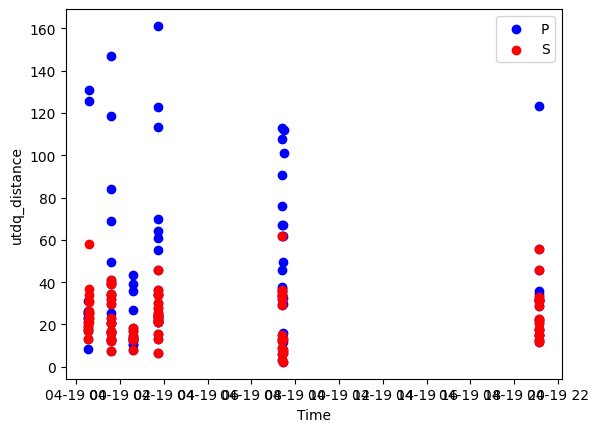

<Axes: xlabel='Time', ylabel='utdq_distance'>

In [ ]:
picks.plot()

let's analyze only one single event. If I am going to edit my object it's better to save a copy to make changes without alterate the previous picks and events object

In [26]:
single_event = events.copy()
single_event_picks = picks.copy()
print(single_event)
print(single_event_picks)

Events | 7 events 
Picks | 354 picks, (7 events-60 stations)


We will manipulate single_event_picks from now. Now, we will use select_data function to select only one event

In [27]:
help(single_event.select_data)

Help on method select_data in module utdquake.core.event.data:

select_data(rowval) method of utdquake.core.event.events.Events instance
    Select rows in the data based on specified criteria.
    
    Parameters:
    -----------
    rowval : dict
        A dictionary specifying the columns and the values to select.
        Keys represent column names, and values are lists of values to filter by.
    
    Returns:
    --------
    self : DataFrameHelper
        The updated DataFrameHelper with only the selected rows.



In [28]:
single_event.select_data(rowval={"ev_id":["tx2024hrey"]})
single_event_picks.select_data(rowval={"ev_id":["tx2024hrey"]})
print(single_event)
print(single_event_picks)

Events | 1 events 
Picks | 46 picks, (1 events-32 stations)


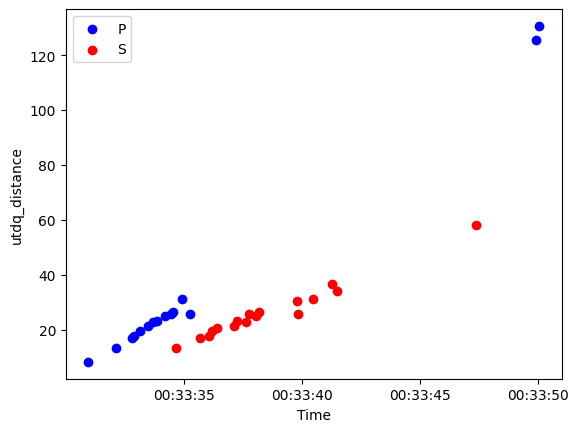

<Axes: xlabel='Time', ylabel='utdq_distance'>

In [ ]:
single_event_picks.plot()

add artificial picks

In [32]:
import numpy as np
distances = np.arange(0,100,10)
single_event_picks.add_artificial_picks(
                           events=single_event,
                           distances=distances,
                           phase_type=["P","S"])
print(single_event_picks)

Picks | 76 picks, (1 events-33 stations)


In [34]:
single_event_picks.P_counts

41

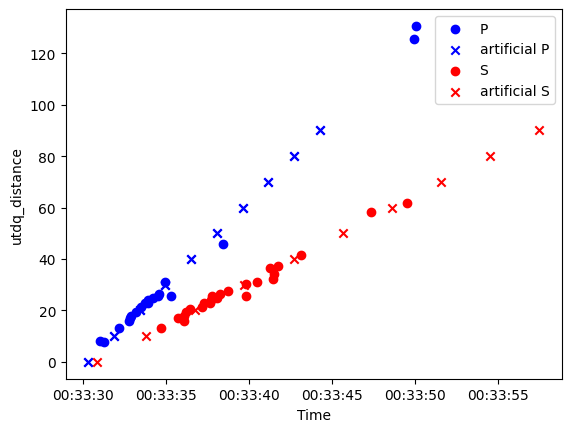

<Axes: xlabel='Time', ylabel='utdq_distance'>

In [33]:
single_event_picks.plot()

# Others

In [ ]:
import pandas as pd

catalog = pd.read_csv(catalog_path)
stations = pd.read_csv(stations_path)

print(catalog.head())
print(stations.head())

        ev_id     ev_type agency                 origin_time  longitude  \
0  tx2024hrey  earthquake     TX  2024-04-19 00:33:29.083274   -103.884   
1  tx2024hrgy  earthquake     TX  2024-04-19 01:33:51.844213   -104.194   
2  tx2024hriz  earthquake     TX  2024-04-19 02:34:59.666935   -103.937   
3  tx2024hrlf  earthquake     TX  2024-04-19 03:43:00.012014   -104.287   
4  tx2024hrwl  earthquake     TX  2024-04-19 09:23:13.067845   -104.410   

   latitude   depth loc_method_id        earth_model_id  magnitude  ...  \
0    31.488  6074.2     NonLinLoc  PB1D-20170918-topoLV        1.8  ...   
1    31.612  4920.7     NonLinLoc  PB1D-20170918-topoLV        1.8  ...   
2    31.605  5920.4     NonLinLoc  PB1D-20170918-topoLV        1.6  ...   
3    31.717  6151.1     NonLinLoc  PB1D-20170918-topoLV        2.6  ...   
4    31.677  5638.4     NonLinLoc  PB1D-20170918-topoLV        2.9  ...   

  qc_magnitude_evaluation_status qc_associated_phase_count  \
0                      confirmed    

picks and mags (all)

In [ ]:
from utdquake.core.database.database import load_from_sqlite

picks = load_from_sqlite(picks_path)
mags = load_from_sqlite(mags_path)

print(picks.head())
print(mags.head())

        ev_id network station location channel phase_hint  \
0  tx2024hrey      TX    PECS       00     HH2          P   
1  tx2024hrey      TX    PECS       00     HH2          S   
2  tx2024hrey      TX    PB40       00     HH1          P   
3  tx2024hrey      TX    PB40       00     HH2          S   
4  tx2024hrey      TX    PB43       00     HH1          P   

                         time  time_lower_error  time_upper_error   author  \
0  2024-04-19 00:33:32.130765               0.2               0.2  Anestis   
1  2024-04-19 00:33:34.698990               0.3               0.3  Anestis   
2  2024-04-19 00:33:32.888062               0.2               0.2  Anestis   
3  2024-04-19 00:33:36.081880               0.2               0.2  Anestis   
4  2024-04-19 00:33:33.497192               0.1               0.1  Anestis   

   ... polarity evaluation_mode evaluation_status time_correction     azimuth  \
0  ...     None          manual              None             0.0  173.168308   
1 

by chunks

In [ ]:
from utdquake.core.database.database import load_chunks_from_sqlite

picks_chunks = load_chunks_from_sqlite(picks_path,chunksize=2)
mags_chunks = load_chunks_from_sqlite(mags_path,chunksize=2)

for picks in picks_chunks:
    print(picks)

for mags in mags_chunks:
    print(mags)

          ev_id network station location channel phase_hint  \
0    tx2024hrey      TX    PECS       00     HH2          P   
1    tx2024hrey      TX    PECS       00     HH2          S   
2    tx2024hrey      TX    PB40       00     HH1          P   
3    tx2024hrey      TX    PB40       00     HH2          S   
4    tx2024hrey      TX    PB43       00     HH1          P   
..          ...     ...     ...      ...     ...        ...   
106  tx2024hrgy      TX    PB12       00     HHZ          P   
107  tx2024hrgy      GM   NMP11       01     HHZ          P   
108  tx2024hrgy      US    MNTX       00     BHZ          P   
109  tx2024hrgy      TX    PB46       00     HHZ          P   
110  tx2024hrgy      TX    PB01       00     HHZ          P   

                           time  time_lower_error  time_upper_error   author  \
0    2024-04-19 00:33:32.130765               0.2               0.2  Anestis   
1    2024-04-19 00:33:34.698990               0.3               0.3  Anestis   
2  